6. АЛГОРИТМ ЦУКАМОТО (Tsukamoto)
Особливість: Вихідні функції належності монотонні (наприклад, прямі лінії).
Дефазифікація: Зважене середнє точних значень Z.

Спрацювали правила:
1. ЯКЩО Температура Висока (alpha=0.6), ТО Доза Середня.
2. ЯКЩО Температура Дуже Висока (alpha=0.2), ТО Доза Велика.

  -> Проекція для правила 1 (z1): 200 + 400 * 0.6 = 440.0 мг
  -> Проекція для правила 2 (z2): 500 + 500 * 0.2 = 600.0 мг

Результат дефазифікації): (0.6*440.0 + 0.2*600.0) / 0.8
Фінальна доза ліків: 480.0 мг



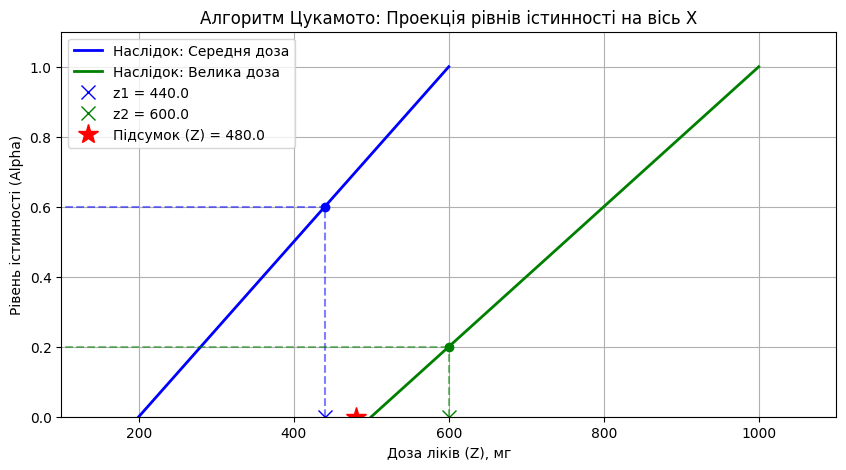

7. АЛГОРИТМ СУГЕНО
Особливість: Наслідок правила це не нечітка множина, а математичне рівняння.
Дефазифікація: Зважене середнє результатів рівнянь.

Вхідні дані: Температура T = 30, Вологість H = 60

Правило 1 (Гаряче І Волого): Вага (w1) = min(0.8, 0.7) = 0.7
  -> Рівняння виходу (z1) = 5*30 + 2*60 = 270 Вт
Правило 2 (Тепло): Вага (w2) = 0.4
  -> Рівняння виходу (z2) = 3*30 = 90 Вт

Результат дефазифікації: (0.7*270 + 0.4*90) / (0.7 + 0.4)
Фінальна потужність: 204.5 Вт



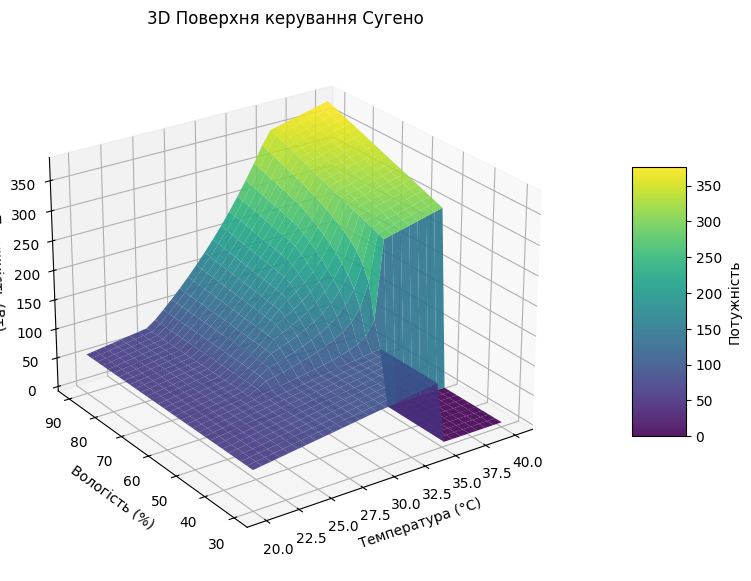

8. АНАЛІЗ ЕКСПЕРТНИХ ВИСЛОВЛЮВАНЬ
Особливість: Формалізація словесного досвіду фахівця у логічні вирази.
Використовуємо t-норми (min) для 'І' та t-конорми (max) для 'АБО'.

Експертне правило: ЯКЩО (Ліквідність Низька І Борг Високий) АБО (Борг Дуже Високий) ТО Ризик Критичний
Дані компанії:
 - Належність до 'Ліквідність Низька': 0.8
 - Належність до 'Борг Високий': 0.6
 - Належність до 'Борг Дуже Високий': 0.3

Обчислення 'І' (min): min(0.8, 0.6) = 0.6
Обчислення 'АБО' (max): max(0.6, 0.3) = 0.6

Результат: Рівень істинності висновку 'Ризик Критичний' становить 0.6
Дія: Призначити додаткову перевірку.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def tsukamoto_example():
    print("="*50)
    print("6. АЛГОРИТМ ЦУКАМОТО (Tsukamoto)")
    print("="*50)
    print("Особливість: Вихідні функції належності монотонні (наприклад, прямі лінії).")
    print("Дефазифікація: Зважене середнє точних значень Z.\n")

    #Сценарій: Розрахунок дози ліків (мг) залежно від температури
    alpha_high_temp = 0.6
    alpha_very_high_temp = 0.2

    print(f"Спрацювали правила:")
    print(f"1. ЯКЩО Температура Висока (alpha={alpha_high_temp}), ТО Доза Середня.")
    print(f"2. ЯКЩО Температура Дуже Висока (alpha={alpha_very_high_temp}), ТО Доза Велика.\n")

    #імплікація
    z1 = 200 + 400 * alpha_high_temp
    print(f"  -> Проекція для правила 1 (z1): 200 + 400 * {alpha_high_temp} = {z1} мг")

    z2 = 500 + 500 * alpha_very_high_temp
    print(f"  -> Проекція для правила 2 (z2): 500 + 500 * {alpha_very_high_temp} = {z2} мг\n")

    #Дефазифікація)
    numerator = (alpha_high_temp * z1) + (alpha_very_high_temp * z2)
    denominator = alpha_high_temp + alpha_very_high_temp
    z_final = numerator / denominator

    print(f"Результат дефазифікації): ({alpha_high_temp}*{z1} + {alpha_very_high_temp}*{z2}) / {denominator}")
    print(f"Фінальна доза ліків: {z_final:.1f} мг\n")

    #ВІЗУАЛІЗАЦІЯ ЦУКАМОТО
    plt.figure(figsize=(10, 5))

    #Функції
    plt.plot([200, 600], [0, 1], 'b-', linewidth=2, label="Наслідок: Середня доза")
    plt.plot([500, 1000], [0, 1], 'g-', linewidth=2, label="Наслідок: Велика доза")

    #Проекції правила 1
    plt.hlines(alpha_high_temp, 0, z1, colors='blue', linestyles='dashed', alpha=0.5)
    plt.vlines(z1, 0, alpha_high_temp, colors='blue', linestyles='dashed', alpha=0.5)
    plt.plot(z1, alpha_high_temp, 'bo')
    plt.plot(z1, 0, 'bx', markersize=10, label=f"z1 = {z1}")

    #Проекції правила 2
    plt.hlines(alpha_very_high_temp, 0, z2, colors='green', linestyles='dashed', alpha=0.5)
    plt.vlines(z2, 0, alpha_very_high_temp, colors='green', linestyles='dashed', alpha=0.5)
    plt.plot(z2, alpha_very_high_temp, 'go')
    plt.plot(z2, 0, 'gx', markersize=10, label=f"z2 = {z2}")

    #результат
    plt.plot(z_final, 0, 'r*', markersize=15, label=f"Підсумок (Z) = {z_final:.1f}")

    plt.title("Алгоритм Цукамото: Проекція рівнів істинності на вісь X")
    plt.xlabel("Доза ліків (Z), мг")
    plt.ylabel("Рівень істинності (Alpha)")
    plt.xlim(100, 1100)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True)
    plt.show(block=False)


def sugeno_example():
    print("="*50)
    print("7. АЛГОРИТМ СУГЕНО")
    print("="*50)
    print("Особливість: Наслідок правила це не нечітка множина, а математичне рівняння.")
    print("Дефазифікація: Зважене середнє результатів рівнянь.\n")

    # Сценарій: Керування потужністю кондиціонера
    T = 30
    H = 60
    print(f"Вхідні дані: Температура T = {T}, Вологість H = {H}\n")

    # Фазифікація
    mu_hot = 0.8
    mu_humid = 0.7
    mu_warm = 0.4

    # Правило 1
    w1 = min(mu_hot, mu_humid)
    z1 = 5 * T + 2 * H
    print(f"Правило 1 (Гаряче І Волого): Вага (w1) = min({mu_hot}, {mu_humid}) = {w1}")
    print(f"  -> Рівняння виходу (z1) = 5*{T} + 2*{H} = {z1} Вт")

    # Правило 2
    w2 = mu_warm
    z2 = 3 * T
    print(f"Правило 2 (Тепло): Вага (w2) = {w2}")
    print(f"  -> Рівняння виходу (z2) = 3*{T} = {z2} Вт\n")

    # Дефазифікація
    z_final = ((w1 * z1) + (w2 * z2)) / (w1 + w2)
    print(f"Результат дефазифікації: ({w1}*{z1} + {w2}*{z2}) / ({w1} + {w2})")
    print(f"Фінальна потужність: {z_final:.1f} Вт\n")

    #ВІЗУАЛІЗАЦІЯ СУГЕНО
    T_grid, H_grid = np.meshgrid(np.linspace(20, 40, 30), np.linspace(30, 90, 30))

    #функції належності для сітки
    mu_hot_grid = np.clip((T_grid - 25) / 15, 0, 1)
    mu_warm_grid = np.clip(1 - abs(T_grid - 25) / 10, 0, 1)
    mu_humid_grid = np.clip((H_grid - 50) / 40, 0, 1)

    #Обчислення для сітки
    w1_grid = np.minimum(mu_hot_grid, mu_humid_grid)
    z1_grid = 5 * T_grid + 2 * H_grid

    w2_grid = mu_warm_grid
    z2_grid = 3 * T_grid

    Z_final_grid = (w1_grid * z1_grid + w2_grid * z2_grid) / (w1_grid + w2_grid + 1e-10)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(T_grid, H_grid, Z_final_grid, cmap='viridis', edgecolor='none', alpha=0.9)

    ax.set_title("3D Поверхня керування Сугено")
    ax.set_xlabel("Температура (°C)")
    ax.set_ylabel("Вологість (%)")
    ax.set_zlabel("Потужність (Вт)")

    fig.colorbar(surf, shrink=0.5, aspect=5, pad=0.1, label='Потужність')
    ax.view_init(elev=25, azim=-125)
    plt.show(block=False)


def expert_analysis_example():
    print("="*50)
    print("8. АНАЛІЗ ЕКСПЕРТНИХ ВИСЛОВЛЮВАНЬ")
    print("="*50)
    print("Особливість: Формалізація словесного досвіду фахівця у логічні вирази.")
    print("Використовуємо t-норми (min) для 'І' та t-конорми (max) для 'АБО'.\n")

    #Оцінка ризику банкрутства
    liquidity_low = 0.8
    debt_high = 0.6
    debt_very_high = 0.3

    print("Експертне правило: ЯКЩО (Ліквідність Низька І Борг Високий) АБО (Борг Дуже Високий) ТО Ризик Критичний")
    print(f"Дані компанії:")
    print(f" - Належність до 'Ліквідність Низька': {liquidity_low}")
    print(f" - Належність до 'Борг Високий': {debt_high}")
    print(f" - Належність до 'Борг Дуже Високий': {debt_very_high}\n")

    # Обчислення
    condition_and = min(liquidity_low, debt_high)
    print(f"Обчислення 'І' (min): min({liquidity_low}, {debt_high}) = {condition_and}")

    final_truth_level = max(condition_and, debt_very_high)
    print(f"Обчислення 'АБО' (max): max({condition_and}, {debt_very_high}) = {final_truth_level}\n")

    print(f"Результат: Рівень істинності висновку 'Ризик Критичний' становить {final_truth_level}")
    if final_truth_level > 0.7:
        print("Дія: Відмовити в кредитуванні.")
    elif final_truth_level > 0.4:
        print("Дія: Призначити додаткову перевірку.")
    else:
        print("Дія: Ризик у межах норми.")
    print("="*50)


if __name__ == "__main__":
    tsukamoto_example()
    sugeno_example()
    expert_analysis_example()
    plt.show()